# 2025-08-18: KNN Label Transfer for Residual and Healthy Plasma Cells
#### By [Aishwarya Chander](aishwarya.chander@alleninstitute.org), High Resolution Translational Immunology, Allen Institute for Immunology

**Main aim**: Assign plasma cell state labels to unlabeled (residual) cells using a distance-weighted KNN classifier (k=30) trained on NDMM state annotations in PCA space.

## 1. Imports

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import scanpy as sc
from scipy.sparse import csr_matrix

sc.settings.set_figure_params(
    dpi=80,
    facecolor='white',
    frameon=False,
    fontsize=14,
    dpi_save=400,
    figsize=(4, 4),
    format='png',
)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from numba.core.errors import NumbaDeprecationWarning
warnings.simplefilter("ignore", category=NumbaDeprecationWarning)
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

In [2]:
adata = sc.read_h5ad('../../../data/rna/plasma-subsets/plasma-knn-labels.h5ad')

## 2. KNN classifier

/home/workspace/environment/scarches/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


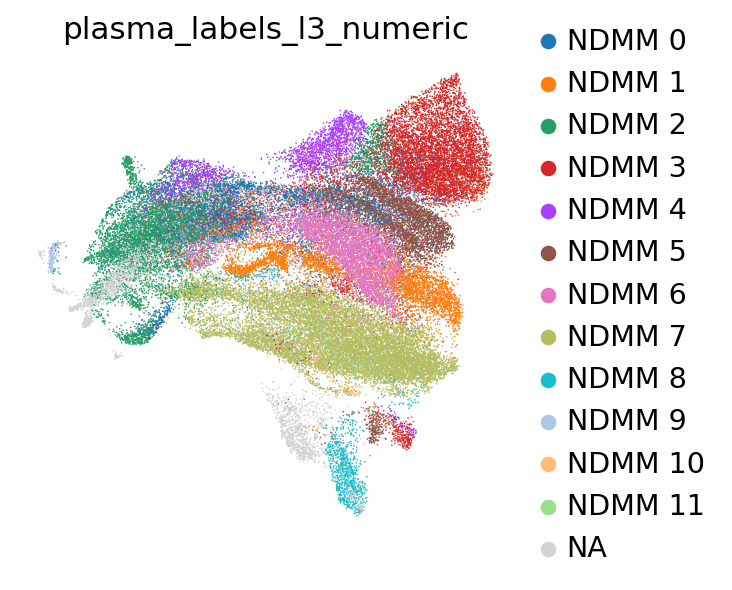

In [3]:
sc.pl.umap(
    adata,
    color=["plasma_labels_l3_numeric"],
    sort_order=False,
    frameon=False
)

In [4]:
from sklearn.neighbors import KNeighborsClassifier

labels = adata.obs["plasma_labels_l3_numeric"].copy()
known = labels.notna()
unknown = labels.isna()

X = adata.obsm["X_pca"]  
knn = KNeighborsClassifier(n_neighbors=100, weights='distance', n_jobs=-1)
knn.fit(X[known], labels[known])

adata.obs["plasma_labels_knn"] = labels 
adata.obs.loc[unknown, "plasma_labels_knn"] = knn.predict(X[unknown])

## 3. View Results

/home/workspace/environment/scarches/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


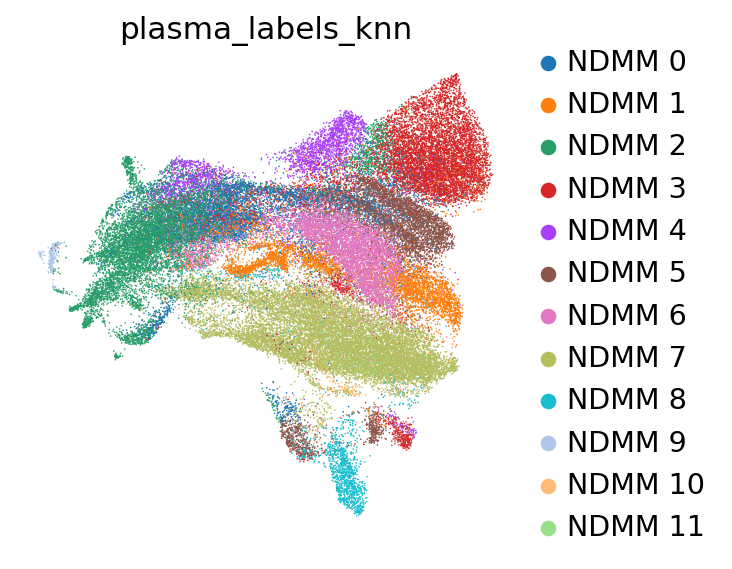

In [5]:
sc.pl.umap(
    adata,
    color=["plasma_labels_knn"],
    sort_order=False,
    frameon=False
)

## 4. Export

In [6]:
adata.obs[['plasma_labels_knn']].to_csv('../../../data/rna/plasma-subsets/knn_predicted_plasma_labels.csv')

In [7]:
residual = adata[adata.obs['sample.visitDetails'] != 'MM Pre-Treatment'].copy()
residual.write('../../../data/rna/plasma-subsets/plasma-residual-labelled.h5ad')